# SWOT along-track SSH spectra analysis

SSHA spectra computed in **Global_SSH_spectra_dask_computation.ipynb** are analysed in this notebook. Maps of number of segments available as well as integrated spectra are shown. Zonal and meridional averages are also plotted.

In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert 

## 1. Configuration


In [2]:
# ── Input files ───────────────────────────────────────────────────────────────
DATA_DIR    = '/Volumes/PortableSSD/'#'/Users/zoecas/Documents/data/'
#DATA_DIR    = '/Users/zoecas/Documents/data/'

DATA_SUBDIR = 'diags_2024/'


# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -60.0,60.0
LON_MIN, LON_MAX = 0.0,360.0

# ── File parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 1000.0
BOX_DEG = 2.0
#filename_pattern = f'{int(SEGMENT_LENGTH_KM)}km_notide_demean_sw6.nc'
filename_pattern ="1000km_demean_swh5.nc"


# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = False   # add internal tide correction (height_cor_xover + internal_tide_hret)

## 3. Defining functions

In [4]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:
    from collections import defaultdict
    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)
    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)
    psd_all    = ds_segments['psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []
    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)
    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max
    psd_stack  = np.stack(rows_psd, axis=0)
    lat_mean   = np.array(rows_lat)
    lon_mean   = np.array(rows_lon)
    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
        ),
        coords=dict(wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
            lat_mean=('box', lat_mean[keep], {'units': 'degrees_north'}),
            lon_mean=('box', lon_mean[keep], {'units': 'degrees_east'}),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

## 4. Loading files
read files and assigns boxes to segments using `build_boxes` if necessary.

In [5]:
ds_segments = xr.open_dataset(DATA_DIR+DATA_SUBDIR+'swot_segments_'+filename_pattern)

print(f'Segment dataset: {ds_segments.sizes}')

#ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15)
#ds_boxes = xr.open_dataset(DATA_DIR+DATA_SUBDIR+'swot_box_spectra_'+filename_pattern)


#print(f'Box dataset: {ds_boxes.sizes["box"]} boxes with at least 1 segment')

#if ds_boxes.box_size_deg!=BOX_DEG:
#    print(f'Box sizes do not match: {ds_boxes.box_size_deg} instead of {BOX_DEG}')
ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15)

## comparing to smaller scales PSD
comparing = True

if comparing:
    ds_segments_250 = xr.open_dataset(DATA_DIR+DATA_SUBDIR+'swot_segments_500km_demean_swh5.nc')
    ds_boxes_250 = build_box_dataset(ds_segments_250, box_deg=BOX_DEG,min_sampling_fraction=0.15)

Segment dataset: Frozen({'segment': 318265, 'wavenumber': 251})


In [6]:
print('Segments per swath:')
for sw in ('left', 'right'):
    n = int((ds_segments['swath'] == sw).sum())
    print(f'  {sw}: {n}')

unique_granules = len(np.unique(ds_segments['granule'].values))
print(f'Unique granules contributing segments: {unique_granules}')
print(f'Boxes with ≥  5 segments: {int((ds_boxes["n_segments"] >=  5).sum())}')
print(f'Boxes with ≥ 10 segments: {int((ds_boxes["n_segments"] >= 10).sum())}')
print(f'Max segments in a box:    {int(ds_boxes["n_segments"].max())}')
print(f'Min segments in a box:    {int(ds_boxes["n_segments"].min())}')

Segments per swath:
  left: 158932
  right: 159333
Unique granules contributing segments: 9981
Boxes with ≥  5 segments: 7486
Boxes with ≥ 10 segments: 7486
Max segments in a box:    72
Min segments in a box:    11


## 5. Diagnostics

In [115]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

def plot_box(var: np.array, lon: np.array, lat: np.array,
             box_deg: float = None,
             projection: ccrs = ccrs.Robinson(), cmap: str = "viridis",
             figsize: tuple = (14, 7),
             title: str = "Number of observations per box", label: str = "Number of observations",
             norm: norm = None, vmin: float = None, vmax: float = None
            ):
    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    # Infer box size from the spacing of box centers if not given
    if box_deg is None:
        lat_diffs = np.diff(np.unique(np.round(lat, 6)))
        lon_diffs = np.diff(np.unique(np.round(lon, 6)))
        box_deg = np.min(np.concatenate([lat_diffs, lon_diffs]))

    # Reconstruct the regular grid of box centers
    lat_centers = np.arange(lat.min(), lat.max() + box_deg, box_deg)
    lon_centers = np.arange(lon.min(), lon.max() + box_deg, box_deg)

    lat_idx = np.round((lat - lat_centers[0]) / box_deg).astype(int)
    lon_idx = np.round((lon - lon_centers[0]) / box_deg).astype(int)

    grid = np.full((lat_centers.size, lon_centers.size), np.nan)
    grid[lat_idx, lon_idx] = var

    # pcolormesh wants cell edges, not centers
    lat_edges = np.concatenate([lat_centers - box_deg / 2, [lat_centers[-1] + box_deg / 2]])
    lon_edges = np.concatenate([lon_centers - box_deg / 2, [lon_centers[-1] + box_deg / 2]])

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}

    if norm is not None:
        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), norm=norm)
    else:
        if vmin is None:
            vmin, vmax = np.nanmin(var), np.nanmax(var)

        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03)
    cb.set_label(label)
    ax.set_title(title)

    return fig, ax

### General statistics

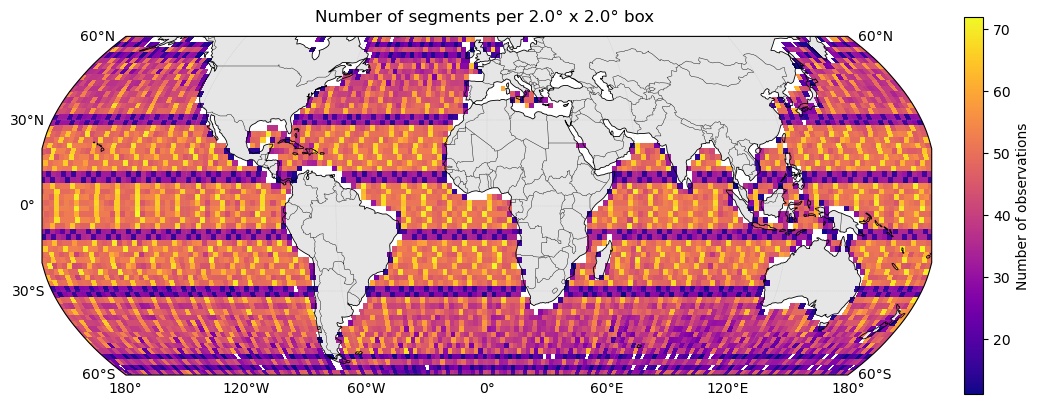

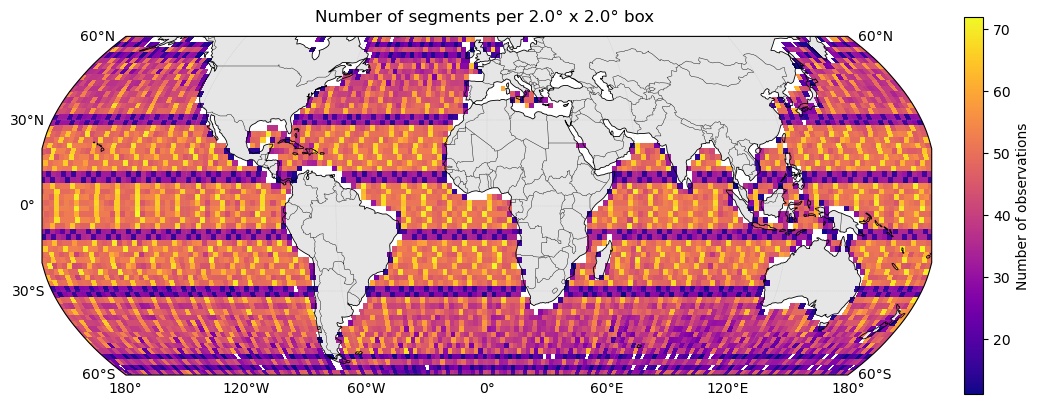

In [9]:

fig, ax = plot_box(ds_boxes["n_segments"].values,
                   ds_boxes["lon_mean"].values,
                   ds_boxes["lat_mean"].values,
                   #projection=ccrs.EqualEarth(),
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

#Removing land segments
MIN_SEGMENTS_PER_BOX = 5
ds_boxes = ds_boxes.where(ds_boxes['n_segments']>=MIN_SEGMENTS_PER_BOX,drop=True)
fig, ax = plot_box(ds_boxes["n_segments"].values,
                   ds_boxes["lon_mean"].values,
                   ds_boxes["lat_mean"].values,
                   #projection=ccrs.EqualEarth(),
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

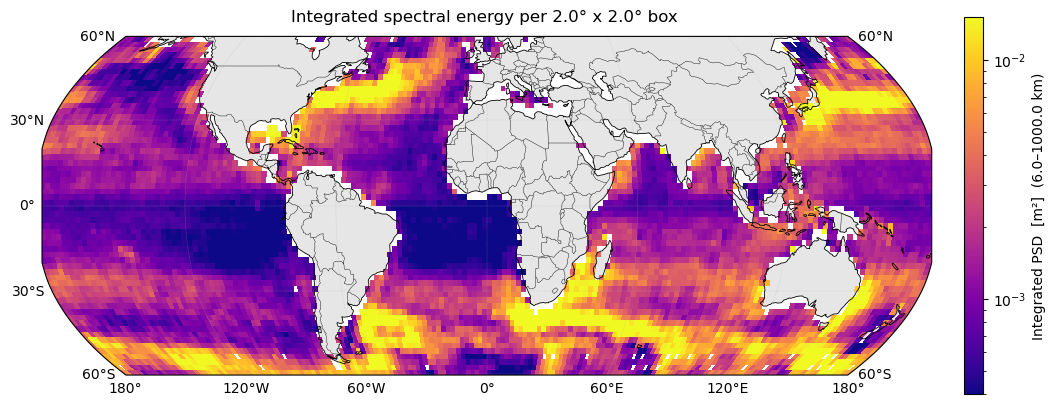

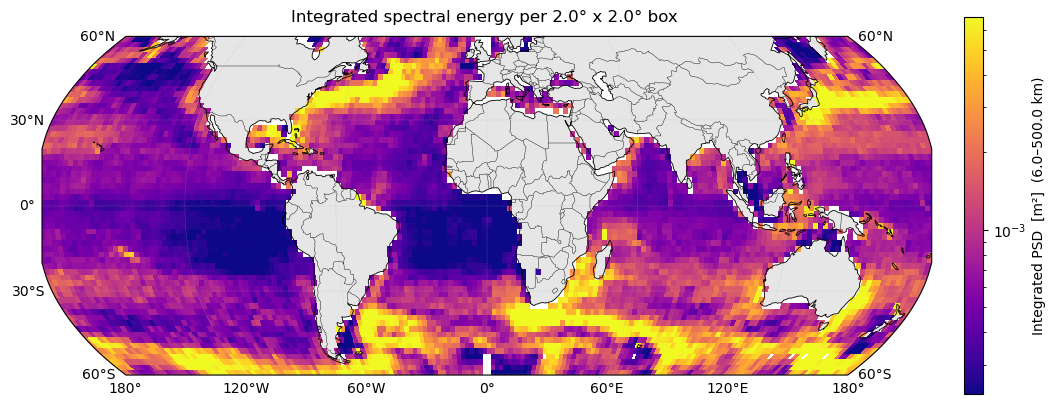

In [10]:
K_MIN, K_MAX = 1/1000, 1/6
k      = ds_boxes['wavenumber'].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy = np.nansum(ds_boxes['mean_psd'].values[:, k_mask] * dk[k_mask], axis=1)

fig, ax = plot_box(energy,ds_boxes["lon_mean"].values,ds_boxes["lat_mean"].values,
                   cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                   label=f'Integrated PSD  [m²]  ({1/K_MAX:.1f}–{1/K_MIN:.1f} km)',
                  norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                       vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

K_MIN, K_MAX = 1/500, 1/6
k      = ds_boxes_250['wavenumber'].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy = np.nansum(ds_boxes_250['mean_psd'].values[:, k_mask] * dk[k_mask], axis=1)

fig, ax = plot_box(energy,ds_boxes_250["lon_mean"].values,ds_boxes_250["lat_mean"].values,
                   cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                   label=f'Integrated PSD  [m²]  ({1/K_MAX:.1f}–{1/K_MIN:.1f} km)',
                  norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                       vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

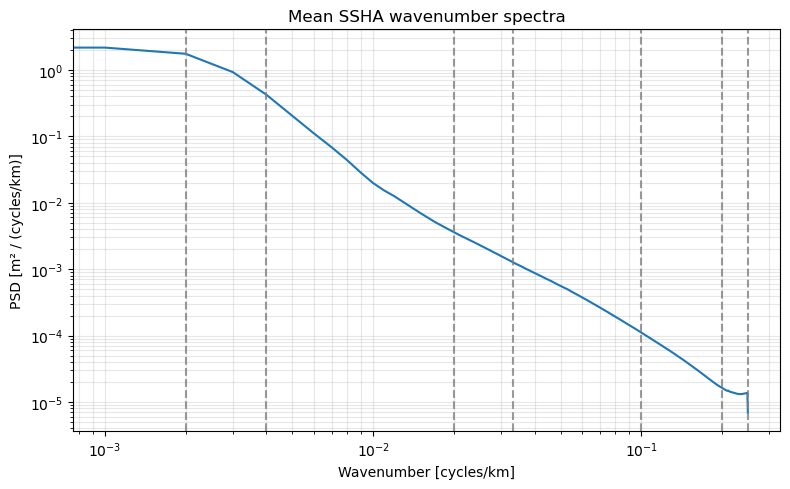

In [11]:
#Defining wavelengths of interest

mean_psd = ds_segments.psd.mean('segment')
mean_psd250 = ds_segments_250.psd.mean('segment')
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(mean_psd["wavenumber"], mean_psd)
#ax.loglog(mean_psd250["wavenumber"], mean_psd250)
# Reference slopes
if False:
    k_ref = ds_segments["wavenumber"].values[2:]
    psd0  = float(ds_boxes["mean_psd"].isel(box=0).values[2])
    k0    = k_ref[0]
    for exp, ls in ((-2, "--"), (-11/3, ":"),(-5,"+-")):
        lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
        ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)
if True:
    for line in [1/500,1/250,1/50,1/30,1/10,1/5,1/4]:
        ax.axvline(line,c='grey',ls='--',alpha=0.8)
#sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#sm.set_array([])
#plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra")
#ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

### Global maps: integrated PSD and spectral slopes

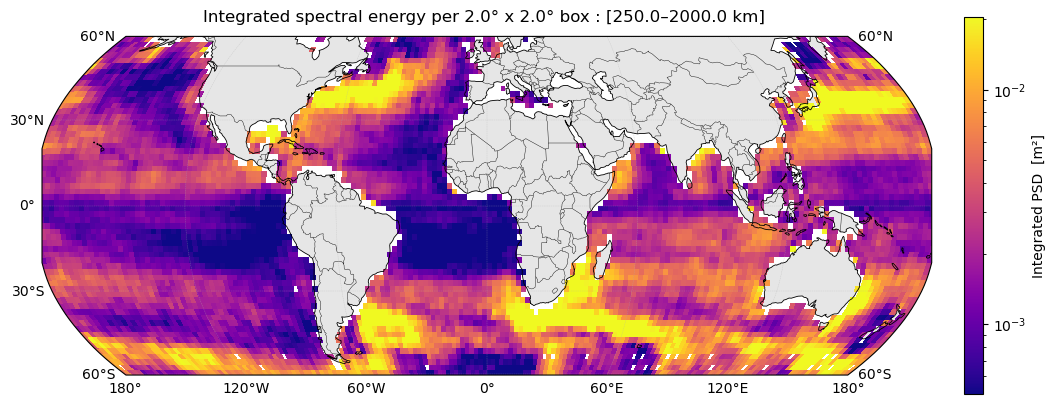

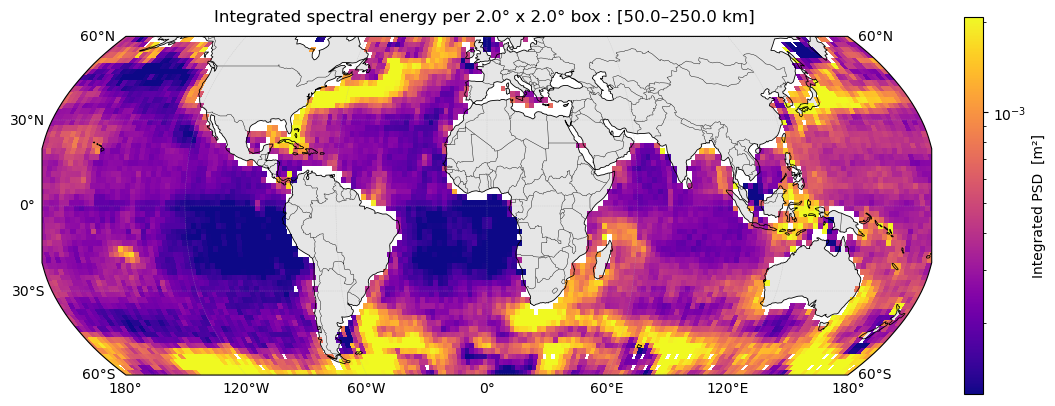

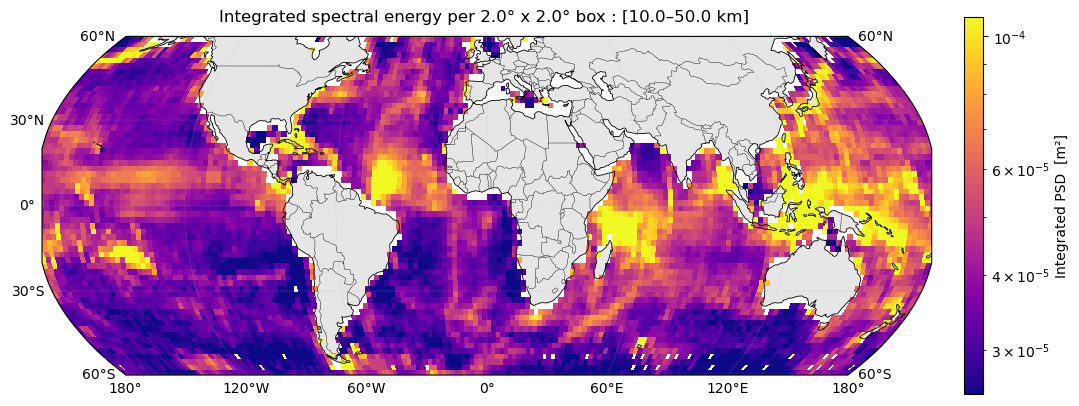

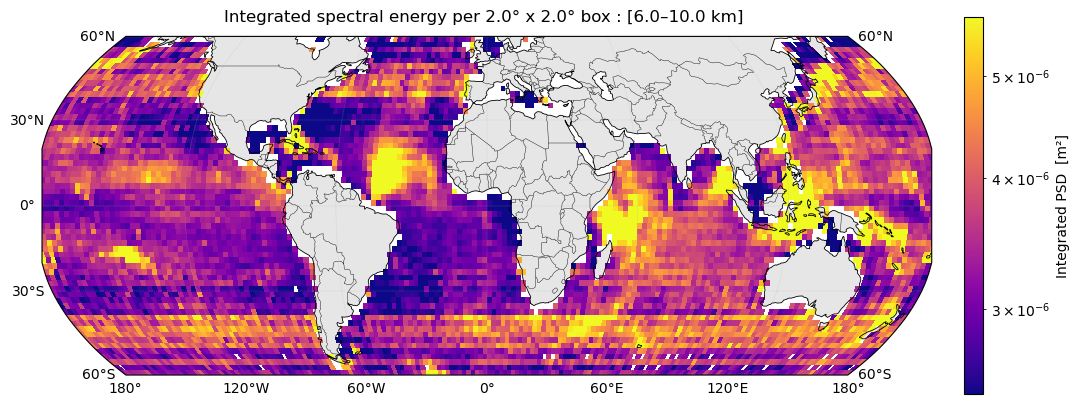

In [12]:
# Integrate the mean PSD over different wavenumber bands
k_min,k_max = [1/SEGMENT_LENGTH_KM/2,1/250,1/50,1/10], [1/250,1/50,1/10,1/6] # /km
for K_MIN,K_MAX in zip(k_min,k_max):
    
    k = ds_boxes["wavenumber"].values
    k_mask = (k >= K_MIN) & (k <= K_MAX)
    dk = np.gradient(k)
    
    psd_vals = ds_boxes["mean_psd"].values          # (n_boxes, nk)
    energy = np.nansum(psd_vals[:, k_mask] * dk[k_mask], axis=1)  # (n_boxes,)
    
    
    fig, ax = plot_box(energy,ds_boxes["lon_mean"].values,ds_boxes["lat_mean"].values,
                       cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Integrated PSD  [m²]',
                      norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                           vmax=np.nanpercentile(energy, 95)))
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

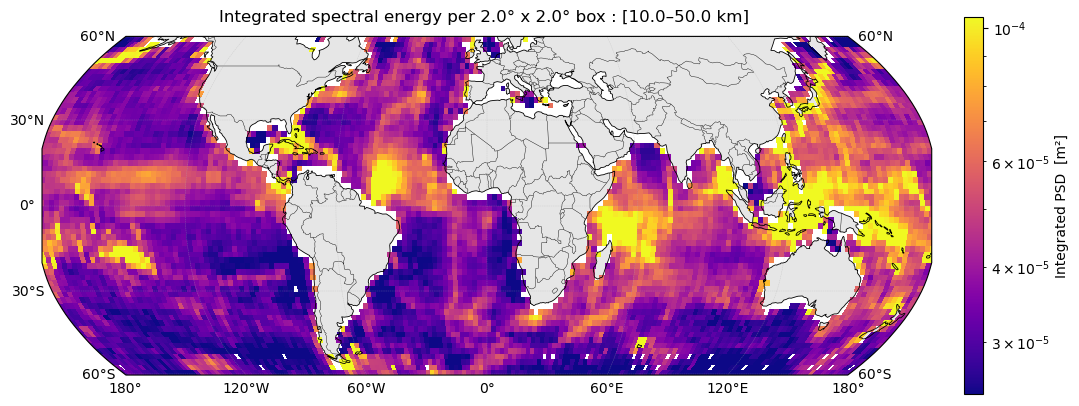

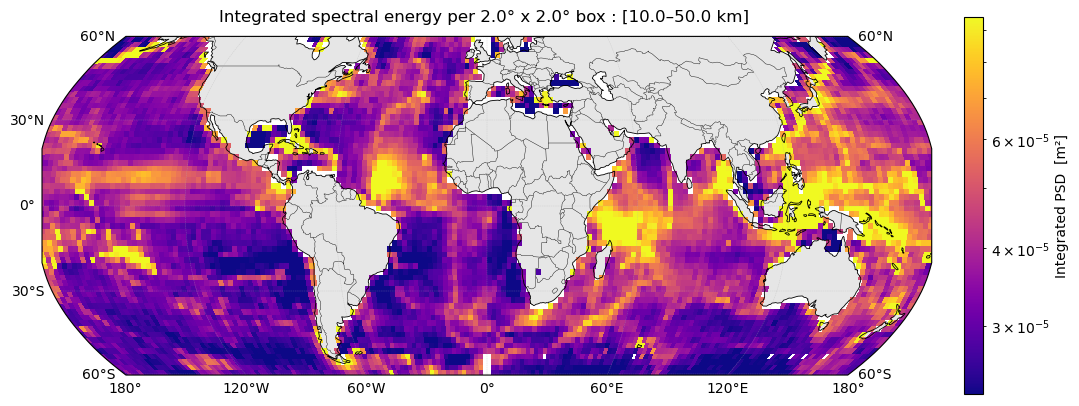

In [13]:
energy = ds_boxes["mean_psd"].sel(wavenumber=slice(1/50,1/10)).integrate('wavenumber')
    
fig, ax = plot_box(energy,ds_boxes["lon_mean"].values,ds_boxes["lat_mean"].values,
                       cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/k_max[-2]:.1f}–{1/k_min[-2]:.1f} km] ",
                       label='Integrated PSD  [m²]',
                      norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                           vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

energy = ds_boxes_250["mean_psd"].sel(wavenumber=slice(1/50,1/10)).integrate('wavenumber')
    
fig, ax = plot_box(energy,ds_boxes_250["lon_mean"].values,ds_boxes_250["lat_mean"].values,
                       cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/k_max[-2]:.1f}–{1/k_min[-2]:.1f} km] ",
                       label='Integrated PSD  [m²]',
                      norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                           vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

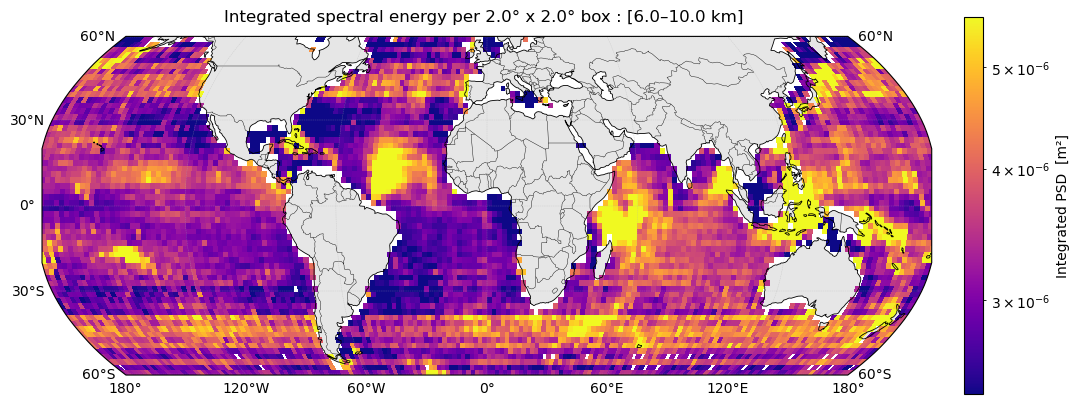

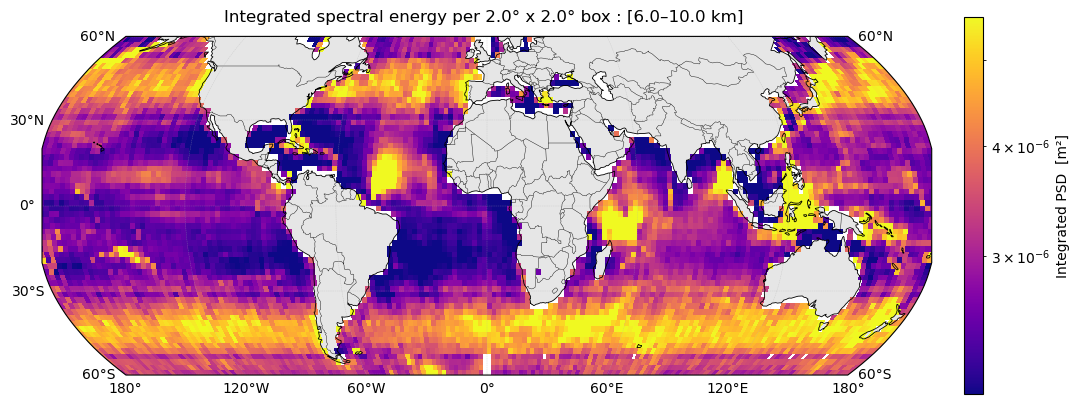

In [14]:
energy = ds_boxes["mean_psd"].sel(wavenumber=slice(1/10,1/6)).integrate('wavenumber')
    
fig, ax = plot_box(energy,ds_boxes["lon_mean"].values,ds_boxes["lat_mean"].values,
                       cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Integrated PSD  [m²]',
                      norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                           vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

energy = ds_boxes_250["mean_psd"].sel(wavenumber=slice(1/10,1/6)).integrate('wavenumber')
    
fig, ax = plot_box(energy,ds_boxes_250["lon_mean"].values,ds_boxes_250["lat_mean"].values,
                       cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Integrated PSD  [m²]',
                      norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                           vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

In [15]:
#Ratio between integrated the mean PSD over different k bands  and total
K_MIN, K_MAX = 1/SEGMENT_LENGTH_KM/2, 1/4
k      = ds_boxes['wavenumber'].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy_total = np.nansum(ds_boxes['mean_psd'].values[:, k_mask] * dk[k_mask], axis=1)

k_min,k_max = [1/SEGMENT_LENGTH_KM/2,1/125,1/50,1/50,1/10], [1/125,1/50,1/5,1/10,1/5] # /km
for K_MIN,K_MAX in zip(k_min,k_max):
    
    k = ds_boxes["wavenumber"].values
    k_mask = (k >= K_MIN) & (k <= K_MAX)
    dk = np.gradient(k)
    
    psd_vals = ds_boxes["mean_psd"].values          # (n_boxes, nk)
    energy = np.nansum(psd_vals[:, k_mask] * dk[k_mask], axis=1) / energy_total  # (n_boxes,)
    
    
    fig, ax = plot_box(energy,ds_boxes["lon_center"].values,ds_boxes["lat_center"].values,
                       cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Integrated PSD  [m²]',vmin=0., vmax=1.0
                      #norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                      #                     vmax=np.nanpercentile(energy, 95))
    )
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

KeyError: "No variable named 'lon_center'. Did you mean one of ('lon_mean',)?"

In [16]:
#Ratio between integrated the mean PSD over different k bands  and total
K_MIN, K_MAX = 1/SEGMENT_LENGTH_KM/2, 1/4
k      = ds_boxes['wavenumber'].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy_total = np.nansum(ds_boxes['mean_psd'].values[:, k_mask] * dk[k_mask], axis=1)

k_min,k_max = [1/SEGMENT_LENGTH_KM/2,1/125,1/50,1/50,1/10], [1/125,1/50,1/5,1/10,1/5] # /km
for K_MIN,K_MAX in zip(k_min,k_max):
    
    k = ds_boxes["wavenumber"].values
    k_mask = (k >= K_MIN) & (k <= K_MAX)
    dk = np.gradient(k)
    
    psd_vals = ds_boxes["mean_psd"].values          # (n_boxes, nk)
    energy = (energy_total-np.nansum(psd_vals[:, k_mask] * dk[k_mask], axis=1)) / energy_total  # (n_boxes,)
    
    
    fig, ax = plot_box(energy,ds_boxes["lon_center"].values,ds_boxes["lat_center"].values,
                       cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Integrated PSD  [m²]',vmin=0., vmax=1.0
                      #norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                      #                     vmax=np.nanpercentile(energy, 95))
    )
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

KeyError: "No variable named 'lon_center'. Did you mean one of ('lon_mean',)?"

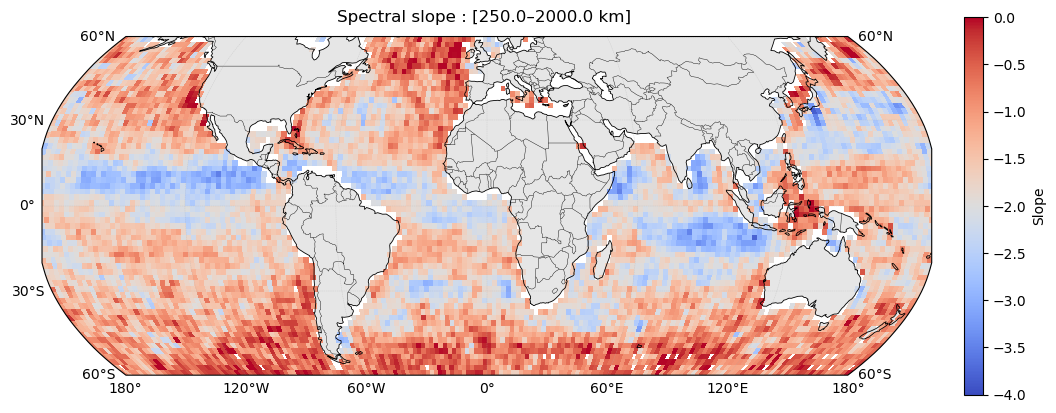

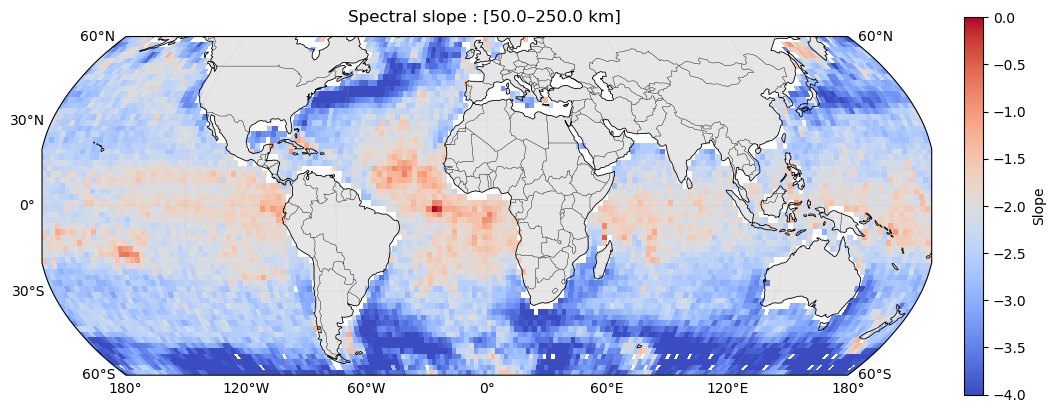

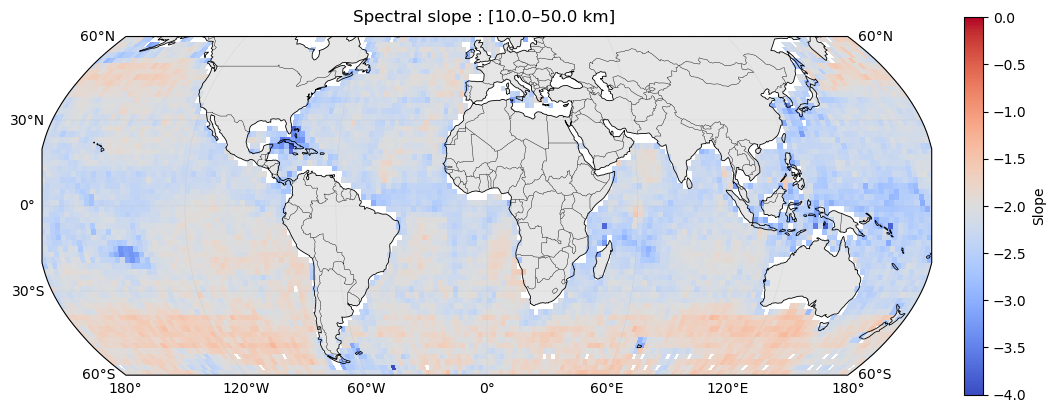

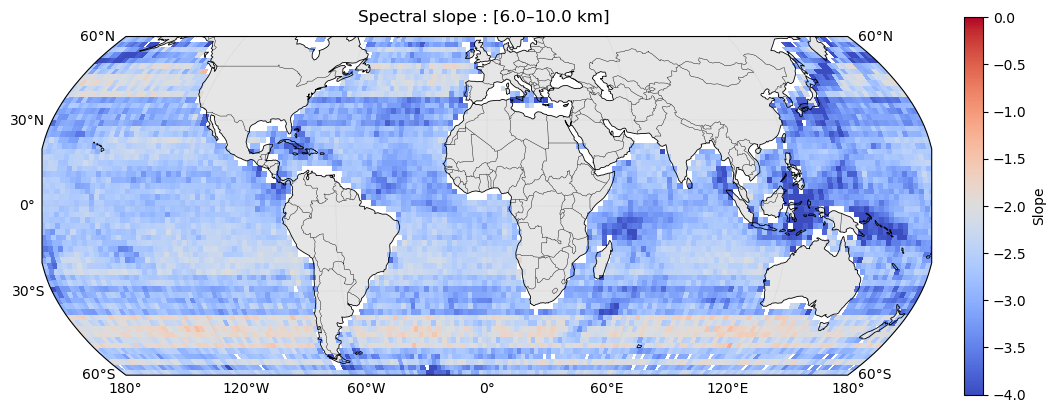

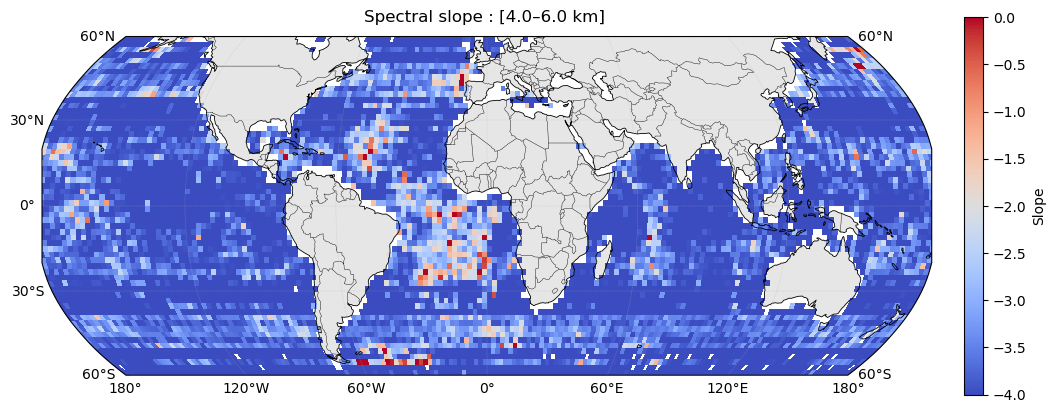

In [17]:
k_min,k_max = [1/SEGMENT_LENGTH_KM/2,1/250,1/50,1/10,1/6], [1/250,1/50,1/10,1/6,1/4] # /km
for K_MIN,K_MAX in zip(k_min,k_max):
    psd_vals = np.log10(ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
    k_vals = np.log10(ds_boxes["wavenumber"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
    slope_mean = (psd_vals.diff('wavenumber') / k_vals.diff('wavenumber')).mean(['wavenumber'])
    #slope_mean = np.nanmean(np.diff(psd_vals[:,k_mask],axis=1)/np.diff(k_vals[k_mask]),axis=1)
    
    fig, ax = plot_box(slope_mean,ds_boxes["lon_mean"].values,ds_boxes["lat_mean"].values,
                       cmap="coolwarm", title=f"Spectral slope : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Slope',vmin=-4,vmax=0
                      #norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                      #                     vmax=np.nanpercentile(energy, 95))
    )
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

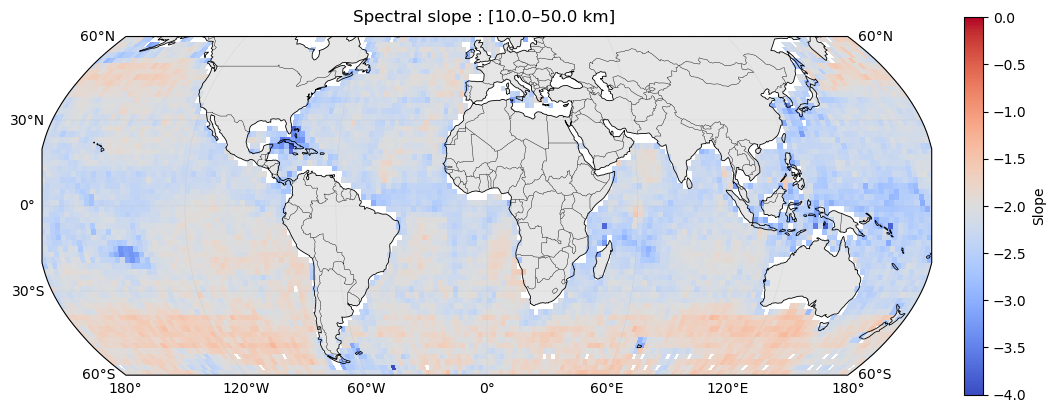

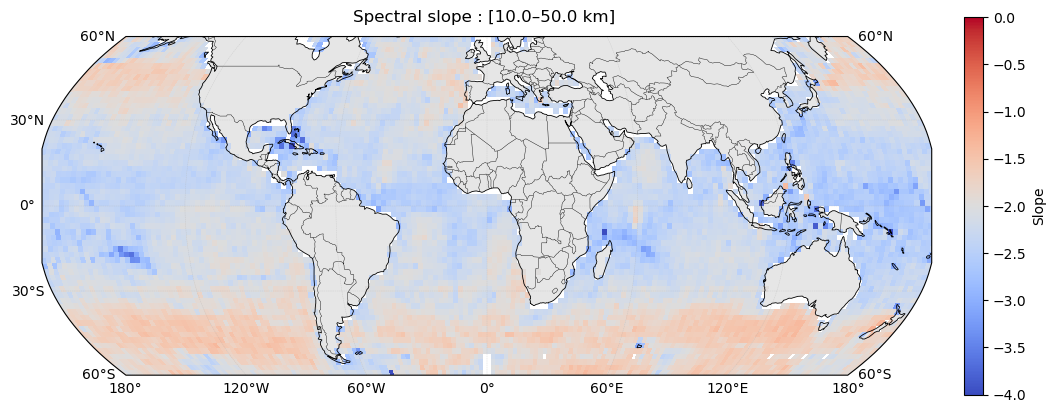

In [18]:
K_MIN,K_MAX = 1/50,1/10
psd_vals = np.log10(ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
k_vals = np.log10(ds_boxes["wavenumber"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
slope_mean = (psd_vals.diff('wavenumber') / k_vals.diff('wavenumber')).mean(['wavenumber'])
    
fig, ax = plot_box(slope_mean,ds_boxes["lon_mean"].values,ds_boxes["lat_mean"].values,
                       cmap="coolwarm", title=f"Spectral slope : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Slope',vmin=-4,vmax=0
                      #norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                      #                     vmax=np.nanpercentile(energy, 95))
    )
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

psd_vals = np.log10(ds_boxes_250["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
k_vals = np.log10(ds_boxes_250["wavenumber"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
slope_mean = (psd_vals.diff('wavenumber') / k_vals.diff('wavenumber')).mean(['wavenumber'])
    
fig, ax = plot_box(slope_mean,ds_boxes_250["lon_mean"].values,ds_boxes_250["lat_mean"].values,
                       cmap="coolwarm", title=f"Spectral slope : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Slope',vmin=-4,vmax=0
                      #norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                      #                     vmax=np.nanpercentile(energy, 95))
    )
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

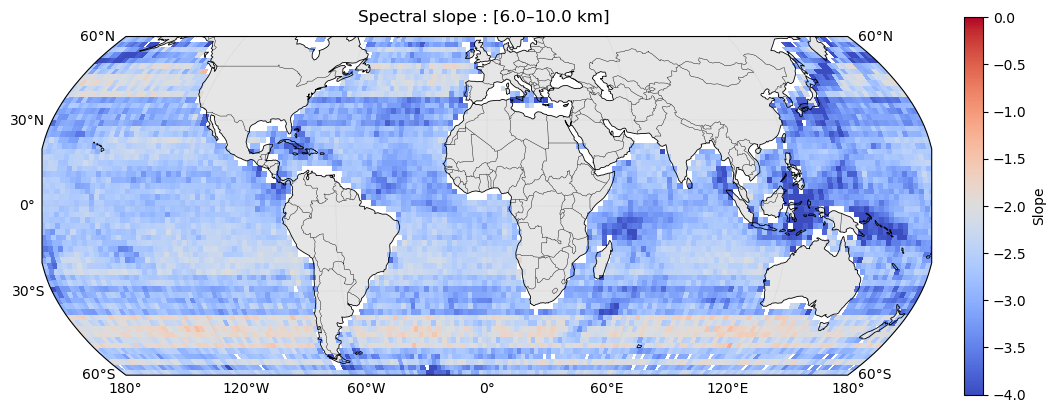

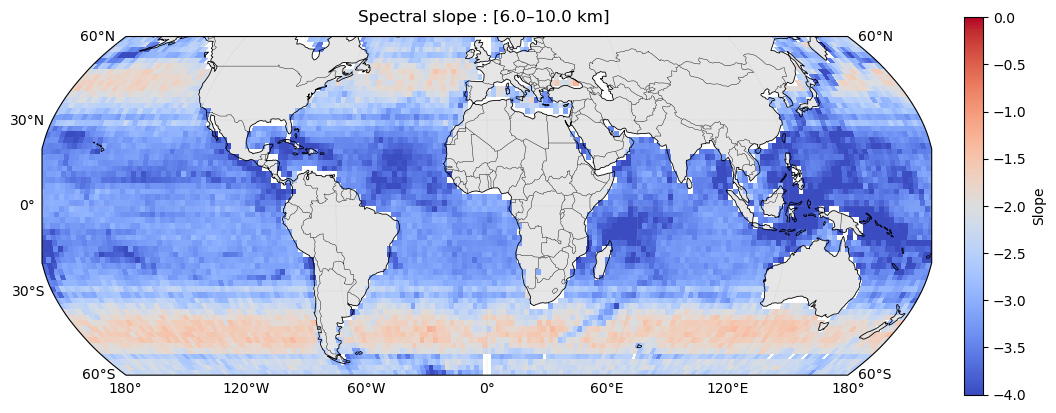

In [19]:
K_MIN,K_MAX = 1/10,1/6
psd_vals = np.log10(ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
k_vals = np.log10(ds_boxes["wavenumber"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
slope_mean = (psd_vals.diff('wavenumber') / k_vals.diff('wavenumber')).mean(['wavenumber'])
    
fig, ax = plot_box(slope_mean,ds_boxes["lon_mean"].values,ds_boxes["lat_mean"].values,
                       cmap="coolwarm", title=f"Spectral slope : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Slope',vmin=-4,vmax=0
                      #norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                      #                     vmax=np.nanpercentile(energy, 95))
    )
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

psd_vals = np.log10(ds_boxes_250["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
k_vals = np.log10(ds_boxes_250["wavenumber"].sel(wavenumber=slice(K_MIN,K_MAX)))          # (n_boxes, nk)
slope_mean = (psd_vals.diff('wavenumber') / k_vals.diff('wavenumber')).mean(['wavenumber'])
    
fig, ax = plot_box(slope_mean,ds_boxes_250["lon_mean"].values,ds_boxes_250["lat_mean"].values,
                       cmap="coolwarm", title=f"Spectral slope : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Slope',vmin=-4,vmax=0
                      #norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                      #                     vmax=np.nanpercentile(energy, 95))
    )
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

## Estimating the spectral separation scale (non-parametric)

Rather than fitting the SSHA wavenumber spectrum to a theoretical two-slope
(or three-slope) model, we estimate the separation scale directly from the
**local slope** of the spectrum in log-log space.

**Method:**
1. Interpolate each box's `log10(PSD)` onto a uniform `log10(wavenumber)` grid
   (required for stable numerical differentiation).
2. Smooth and differentiate using a Savitzky-Golay filter, which fits a local
   polynomial (order `polyorder`) over a sliding window (`smooth_window`
   points) and returns its analytical derivative — this gives a smoothed
   estimate of the local slope `d(log PSD)/d(log k)` at every wavenumber,
   without imposing any global functional form on the spectrum.
3. The **separation wavenumber** is defined as the wavenumber where this
   local slope first crosses a reference value (`slope_threshold`, default
   −2), consistent with the transition from a shallower "balanced/mesoscale"
   regime to a steeper high-wavenumber regime seen in SSHA spectra.
4. The search is restricted to a physically reasonable wavenumber range
   (`wavenumber_range`) to avoid spurious crossings from the instrument
   noise floor at small scales or edge artifacts at the largest scales.

This yields a per-box separation wavenumber/wavelength with no assumptions
about the number of spectral regimes or their functional shape — only that
the local slope varies smoothly enough to be estimated after modest
smoothing.

In [20]:
import numpy as np
import xarray as xr
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d


def estimate_separation_scale(ds_box: xr.Dataset,
                               slope_threshold: float = -2.0,
                               smooth_window: int = 11,
                               polyorder: int = 2,
                               wavenumber_range: tuple = None,
                               n_interp: int = 200,
                               verbose: bool = False) -> xr.Dataset:
    """
    Estimate a non-parametric spectral separation scale per box from
    build_box_dataset output, based on where the local log-log slope
    of the PSD crosses `slope_threshold`.
    """
    wavenumber = ds_box['wavenumber'].values
    psd_all    = ds_box['mean_psd'].values
    n_boxes    = psd_all.shape[0]

    # --- critical fix: drop k <= 0 before taking log10 ---
    k_valid_mask = wavenumber > 0
    if not np.all(k_valid_mask):
        if verbose:
            print(f"Dropping {np.sum(~k_valid_mask)} non-positive wavenumber bin(s) "
                  f"(e.g. DC component) before log10.")
    wavenumber = wavenumber[k_valid_mask]
    psd_all = psd_all[:, k_valid_mask]

    if smooth_window % 2 == 0:
        smooth_window += 1

    log_k_orig = np.log10(wavenumber)
    log_k_uniform = np.linspace(log_k_orig.min(), log_k_orig.max(), n_interp)
    dlogk = log_k_uniform[1] - log_k_uniform[0]

    if wavenumber_range is not None:
        k_lo, k_hi = wavenumber_range
    else:
        k_lo, k_hi = wavenumber.min(), wavenumber.max()
    search_mask = (10**log_k_uniform >= k_lo) & (10**log_k_uniform <= k_hi)

    separation_k = np.full(n_boxes, np.nan)
    local_slope_all = np.full((n_boxes, n_interp), np.nan)

    for i in range(n_boxes):
        p = psd_all[i]
        valid = np.isfinite(p) & (p > 0)
        if valid.sum() < smooth_window:
            if verbose:
                print(f"Box {i}: only {valid.sum()} finite/positive PSD points, skipping.")
            continue

        log_psd_interp_fn = interp1d(log_k_orig[valid], np.log10(p[valid]),
                                      bounds_error=False, fill_value=np.nan)
        log_psd_uniform = log_psd_interp_fn(log_k_uniform)

        valid_u = ~np.isnan(log_psd_uniform)
        n_valid_u = valid_u.sum()
        if n_valid_u < polyorder + 2:
            if verbose:
                print(f"Box {i}: only {n_valid_u} valid interpolated points, skipping.")
            continue

        # window must be odd, <= n_valid_u, and > polyorder
        win = min(smooth_window, n_valid_u if n_valid_u % 2 == 1 else n_valid_u - 1)
        if win <= polyorder:
            if verbose:
                print(f"Box {i}: window {win} too small for polyorder {polyorder}, skipping.")
            continue

        slope = np.full(n_interp, np.nan)
        try:
            slope[valid_u] = savgol_filter(log_psd_uniform[valid_u],
                                            window_length=win,
                                            polyorder=polyorder,
                                            deriv=1, delta=dlogk)
        except Exception as e:
            if verbose:
                print(f"Box {i}: savgol_filter failed ({e}), skipping.")
            continue

        local_slope_all[i] = slope

        mask = search_mask & valid_u
        idxs = np.where(mask)[0]
        if len(idxs) < 2:
            if verbose:
                print(f"Box {i}: fewer than 2 points in search range, skipping.")
            continue

        diff = slope[idxs] - slope_threshold
        sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]
        if len(sign_change) == 0:
            if verbose:
                print(f"Box {i}: slope never crosses {slope_threshold} "
                      f"(range: {np.nanmin(slope[idxs]):.2f} to {np.nanmax(slope[idxs]):.2f}).")
            continue

        j = sign_change[0]
        frac = -diff[j] / (diff[j + 1] - diff[j])
        i1, i2 = idxs[j], idxs[j + 1]
        log_k_cross = log_k_uniform[i1] + frac * (log_k_uniform[i2] - log_k_uniform[i1])
        separation_k[i] = 10 ** log_k_cross

    ds_out = ds_box.copy()
    ds_out['local_slope'] = (
        ['box', 'log_wavenumber'], local_slope_all,
        {'long_name': f'Local log-log slope (Savitzky-Golay, window={smooth_window}, order={polyorder})'}
    )
    ds_out.coords['log_wavenumber'] = ('log_wavenumber', 10**log_k_uniform, {'units': 'cycles/km'})
    ds_out['separation_wavenumber'] = (
        ['box'], separation_k,
        {'long_name': f'Wavenumber where local slope crosses {slope_threshold}',
         'units': 'cycles/km'}
    )
    ds_out['separation_wavelength'] = (
        ['box'], 1.0 / separation_k,
        {'long_name': 'Separation scale (1/wavenumber)', 'units': 'km'}
    )
    return ds_out

In [119]:
ds_sep = estimate_separation_scale(ds_boxes,smooth_window=11,wavenumber_range=(1/150, 1/10))
ds_sep250 = estimate_separation_scale(ds_boxes_250,smooth_window=11,wavenumber_range=(1/150, 1/10))


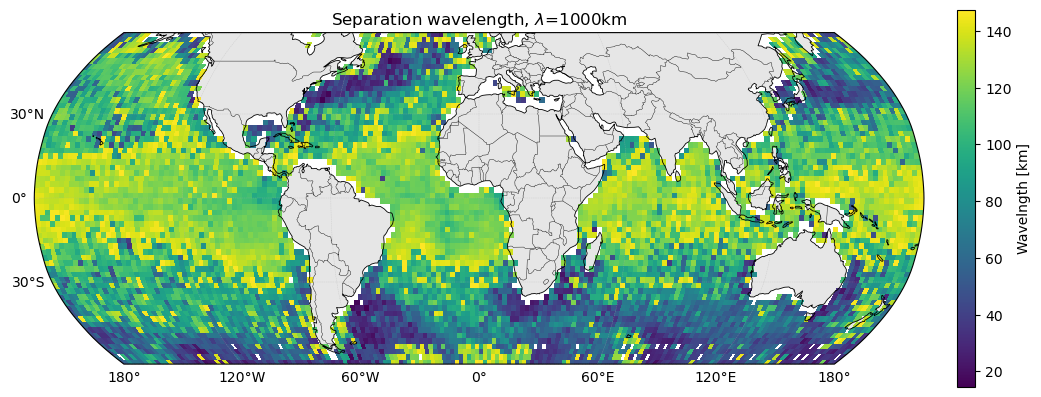

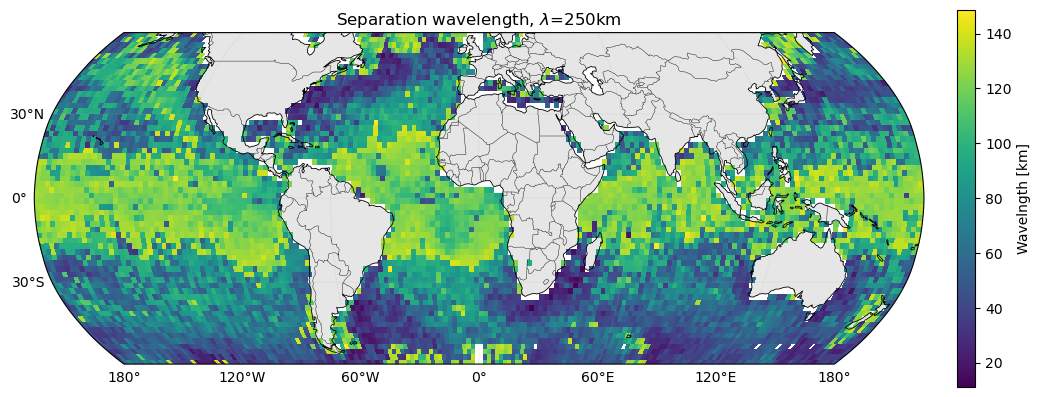

In [120]:
fig, ax = plot_box(ds_sep.separation_wavelength
                   ,ds_sep.lon_mean,ds_sep.lat_mean, title = r"Separation wavelength, $\lambda$=1000km", label=r'Wavelngth [km]')
ax.set_extent([-180,180,-60,60])

fig, ax = plot_box(ds_sep250.separation_wavelength
                   ,ds_sep250.lon_mean,ds_sep250.lat_mean, title = r"Separation wavelength, $\lambda$=250km", label=r'Wavelngth [km]')
ax.set_extent([-180,180,-60,60])

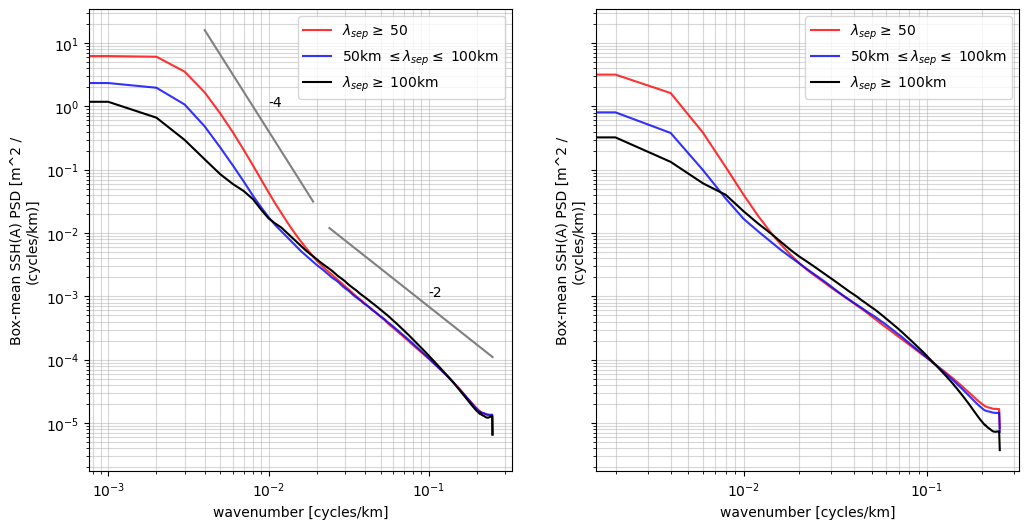

In [121]:
fig, axs = plt.subplots(1,2,figsize=(12,6), sharey=True)
ax=axs[0]
ds_boxes.where((ds_sep.separation_wavelength<50),drop=True
              ).mean_psd.mean('box').plot(ax=ax,xscale='log', yscale='log', c='r', alpha = 0.8,  label=r'$\lambda_{sep} \geq $ 50')
ds_boxes.where((ds_sep.separation_wavelength<100) & (ds_sep.separation_wavelength>=50),drop=True
              ).mean_psd.mean('box').plot(ax=ax,xscale='log', yscale='log', c='b', alpha = 0.8, label=r'50km $\leq\lambda_{sep} \leq $ 100km')
ds_boxes.where(ds_sep.separation_wavelength>=100,drop=True
              ).mean_psd.mean('box').plot(ax=ax,xscale='log', yscale='log',c='k',label=r'$\lambda_{sep} \geq $ 100km')

ax=axs[1]
ds_boxes_250.where((ds_sep250.separation_wavelength<50),drop=True
              ).mean_psd.mean('box').plot(ax=ax,xscale='log', yscale='log', c='r', alpha = 0.8,  label=r'$\lambda_{sep} \geq $ 50')
ds_boxes_250.where((ds_sep250.separation_wavelength<100) & (ds_sep250.separation_wavelength>=50),drop=True
              ).mean_psd.mean('box').plot(ax=ax,xscale='log', yscale='log', c='b', alpha = 0.8, label=r'50km $\leq\lambda_{sep} \leq $ 100km')
ds_boxes_250.where(ds_sep250.separation_wavelength>=100,drop=True
              ).mean_psd.mean('box').plot(ax=ax,xscale='log', yscale='log',c='k',label=r'$\lambda_{sep} \geq $ 100km')


# Reference slopes
ax=axs[0]
k_ref = ds_boxes["wavenumber"].values[4:20]
k0    = k_ref[4]
psd0 = 1
ax.loglog(k_ref, psd0 * (k_ref / k0) ** -4,color='gray')
ax.text(0.01,1,'-4')
k_ref = ds_boxes["wavenumber"].values[24:]
k0    = k_ref[24]
psd0 = 3e-3
ax.loglog(k_ref, psd0 * (k_ref / k0) ** -2,color='gray')
ax.text(0.1,0.001,'-2')
for ax in axs:
    ax.grid(True, which='both', alpha=0.5)
    ax.legend()






In [122]:
def plot_integrated_psd_with_separation(ds_box: xr.Dataset, ds_sep: xr.Dataset,
                                         separation_threshold_km: float = 50.0,
                                         box_deg: float = None,
                                         projection: ccrs = ccrs.Robinson(),
                                         cmap: str = "viridis",
                                         figsize: tuple = (14, 7),
                                         title: str = "Integrated PSD, hatched where separation wavelength < 50 km",
                                         label: str = "Integrated PSD [m$^2$]",
                                         vmin: float = None, vmax: float = None,
                                         hatch: str = "//"):
    """
    Map of wavenumber-integrated PSD per box, with hatching over boxes
    where separation_wavelength < separation_threshold_km.

    Parameters
    ----------
    ds_sep : xr.Dataset
        Output of estimate_separation_scale (has 'mean_psd', 'wavenumber',
        'lat_mean', 'lon_mean', 'separation_wavelength').
    separation_threshold_km : float
        Threshold in km; boxes with separation_wavelength below this are hatched.
    box_deg : float, optional
        Box size in degrees; defaults to ds_sep.attrs['box_size_deg'].
    """
    if box_deg is None:
        box_deg = ds_sep.attrs.get('box_size_deg', 2.0)

    lat = ds_box['lat_mean'].values
    lon = ds_box['lon_mean'].values

    # --- Integrate PSD over wavenumber (trapezoidal rule) ---
    wavenumber = ds_box['wavenumber'].values
    psd = ds_box['mean_psd'].values  # (box, wavenumber)
    integrated_psd = np.trapezoid(psd, x=wavenumber, axis=1)

    sep_wavelength = ds_sep['separation_wavelength'].values
    small_sep_mask = np.isfinite(sep_wavelength) & (sep_wavelength < separation_threshold_km)

    mask = np.isfinite(integrated_psd)
    lat_m, lon_m, val_m, hatch_mask_m = lat[mask], lon[mask], integrated_psd[mask], small_sep_mask[mask]

    # --- Reconstruct regular grid from box centers ---
    lat_centers = np.arange(lat_m.min(), lat_m.max() + box_deg, box_deg)
    lon_centers = np.arange(lon_m.min(), lon_m.max() + box_deg, box_deg)

    lat_idx = np.round((lat_m - lat_centers[0]) / box_deg).astype(int)
    lon_idx = np.round((lon_m - lon_centers[0]) / box_deg).astype(int)

    grid = np.full((lat_centers.size, lon_centers.size), np.nan)
    grid[lat_idx, lon_idx] = val_m

    hatch_grid = np.zeros((lat_centers.size, lon_centers.size), dtype=bool)
    hatch_grid[lat_idx, lon_idx] = hatch_mask_m

    lat_edges = np.concatenate([lat_centers - box_deg / 2, [lat_centers[-1] + box_deg / 2]])
    lon_edges = np.concatenate([lon_centers - box_deg / 2, [lon_centers[-1] + box_deg / 2]])

    if vmin is None:
        vmin, vmax = np.nanpercentile(val_m,5), np.nanpercentile(val_m,95)

    # --- Plot ---
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}

    mesh = ax.pcolormesh(lon_edges, lat_edges, grid, cmap=cmap, shading='flat',
                          transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)
    cb = plt.colorbar(mesh, ax=ax, shrink=0.7, pad=0.03)
    cb.set_label(label)

    # Overlay hatching where separation wavelength < threshold.
    # contourf with a fully transparent facecolor + hatch pattern is the
    # standard cartopy/matplotlib trick for hatch-only overlays.
    lon_grid_c, lat_grid_c = np.meshgrid(lon_centers, lat_centers)
    if hatch_grid.any():
        ax.contourf(lon_grid_c, lat_grid_c, hatch_grid.astype(int),
                    levels=[0.5, 1.5], hatches=[hatch], colors='none',
                    transform=ccrs.PlateCarree())

    ax.set_title(f"{title} (threshold={separation_threshold_km} km)")

    return fig, ax

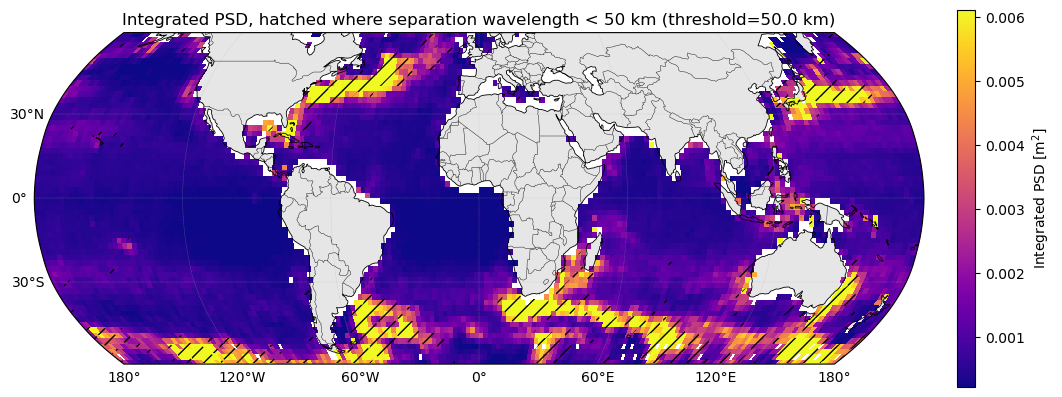

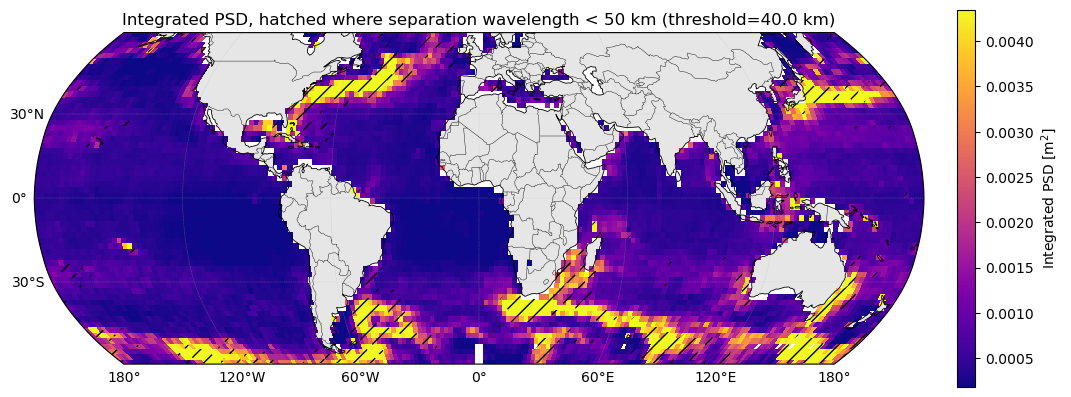

In [123]:
fig, ax = plot_integrated_psd_with_separation(ds_boxes.sel(wavenumber=slice(1/500,1/10)), ds_sep, separation_threshold_km=50.0, cmap='plasma')
ax.set_extent([-180,180,-60,60])
plt.show()

fig, ax = plot_integrated_psd_with_separation(ds_boxes_250.sel(wavenumber=slice(1/500,1/10)), ds_sep250, separation_threshold_km=40.0, cmap='plasma')
ax.set_extent([-180,180,-60,60])
plt.show()

In [124]:
def integrate_psd_range(wavenumber: np.ndarray, psd: np.ndarray,
                         k_lo: float, k_hi: float) -> float:
    """
    Integrate PSD(k) over [k_lo, k_hi] using the trapezoidal rule,
    linearly interpolating PSD at the exact bounds so the result
    isn't restricted to existing wavenumber grid points.

    Returns NaN if the range is invalid or falls outside the
    available wavenumber support.
    """
    if not (np.isfinite(k_lo) and np.isfinite(k_hi)) or k_lo >= k_hi:
        return np.nan
    if k_lo < wavenumber.min() or k_hi > wavenumber.max():
        return np.nan  # requested range not covered by data

    valid = np.isfinite(psd)
    if valid.sum() < 2:
        return np.nan

    k = wavenumber[valid]
    p = psd[valid]

    # Points strictly inside (k_lo, k_hi)
    inside = (k > k_lo) & (k < k_hi)
    k_sub = k[inside]
    p_sub = p[inside]

    # Interpolate PSD at the exact boundaries
    p_lo = np.interp(k_lo, k, p)
    p_hi = np.interp(k_hi, k, p)

    k_full = np.concatenate([[k_lo], k_sub, [k_hi]])
    p_full = np.concatenate([[p_lo], p_sub, [p_hi]])

    return np.trapezoid(p_full, x=k_full)


def add_integrated_psd_highk(ds_sep: xr.Dataset,
                              k_hi: float = 1 / 10) -> xr.Dataset:
    """
    Add 'integrated_psd_highk' to ds_sep: PSD integrated from each box's
    separation_wavenumber up to k_hi (default: wavelength = 10 km).
    """
    wavenumber = ds_sep['wavenumber'].values
    psd_all = ds_sep['mean_psd'].values
    k_sep_all = ds_sep['separation_wavenumber'].values

    n_boxes = psd_all.shape[0]
    integrated = np.full(n_boxes, np.nan)
    for i in range(n_boxes):
        integrated[i] = integrate_psd_range(wavenumber, psd_all[i], max(1/50,k_sep_all[i]), k_hi)

    ds_out = ds_sep.copy()
    ds_out['integrated_psd_highk'] = (
        ['box'], integrated,
        {'long_name': f'PSD integrated from separation wavenumber to k={k_hi:.3g} cyc/km',
         'units': 'm^2'}
    )
    return ds_out

In [125]:
ds_sep = add_integrated_psd_highk(ds_sep)


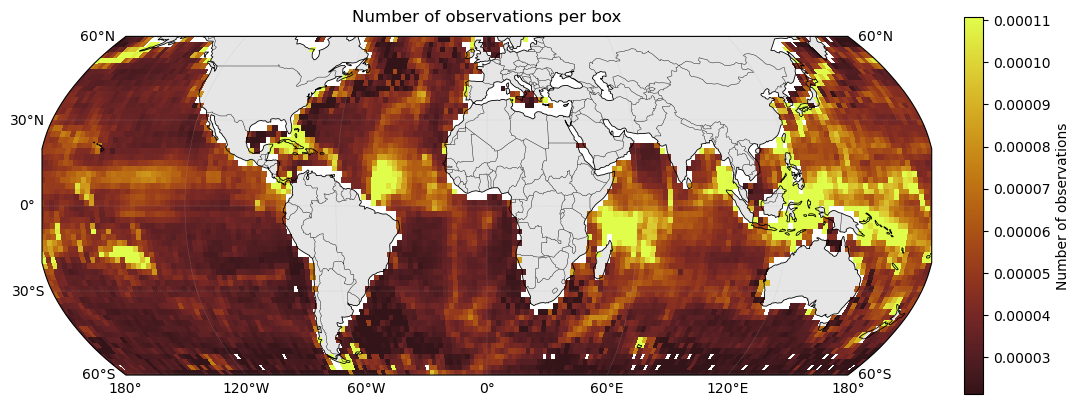

In [128]:
import cmocean
fig,ax = plot_box(ds_sep.integrated_psd_highk,ds_sep['lon_mean'],ds_sep['lat_mean'],
                 vmin=np.nanpercentile(ds_sep.integrated_psd_highk,5),vmax=np.nanpercentile(ds_sep.integrated_psd_highk,95),
                 cmap= cmocean.cm.solar)
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())

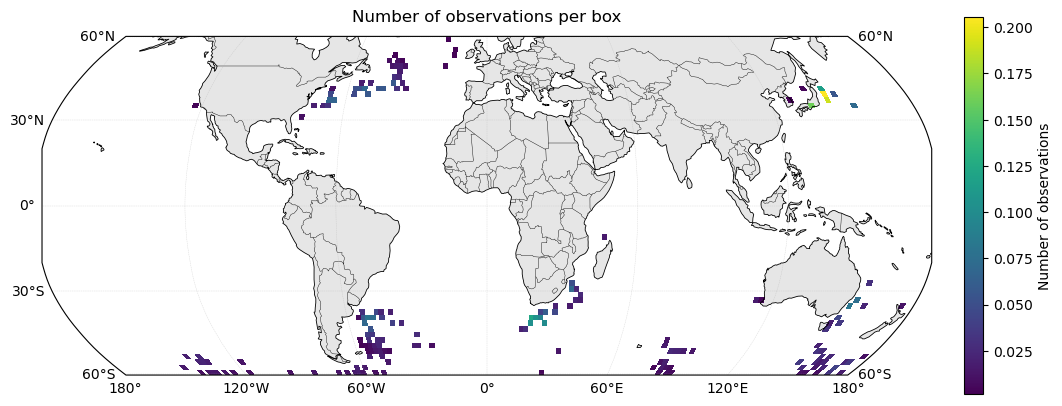

In [103]:
energy = ds_boxes.where(ds_sep.separation_wavelength<=30).mean_psd.integrate('wavenumber')
fig,ax = plot_box(energy,ds_boxes['lon_mean'],ds_boxes['lat_mean'])
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())


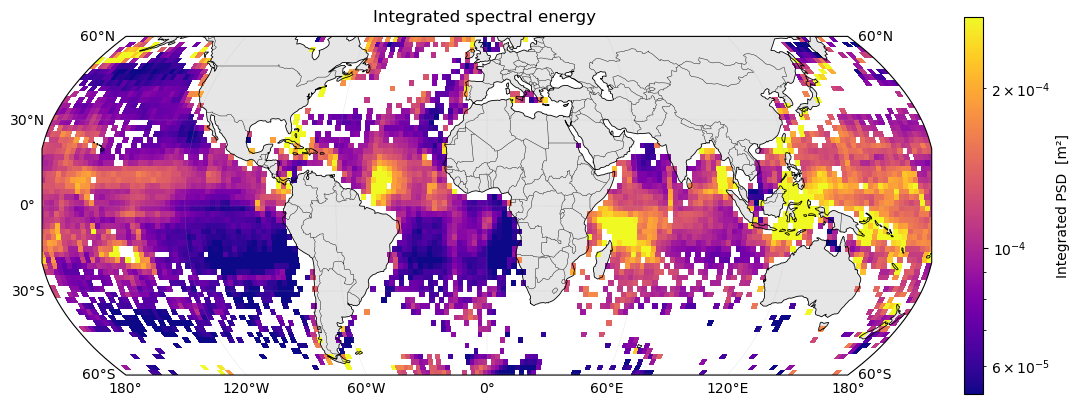

In [97]:
sub_kband = ds_boxes.where(ds_sep.separation_wavelength<=ds_boxes['kmin'],drop=True).sel(wavenumber=slice(None,1/10))
fig, ax = plot_box(sub_kband.mean_psd.integrate('wavenumber'),sub_kband["lon_mean"].values,sub_kband["lat_mean"].values,
                       cmap="plasma", title=f"Integrated spectral energy ",
                       label='Integrated PSD  [m²]',
                      norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                           vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

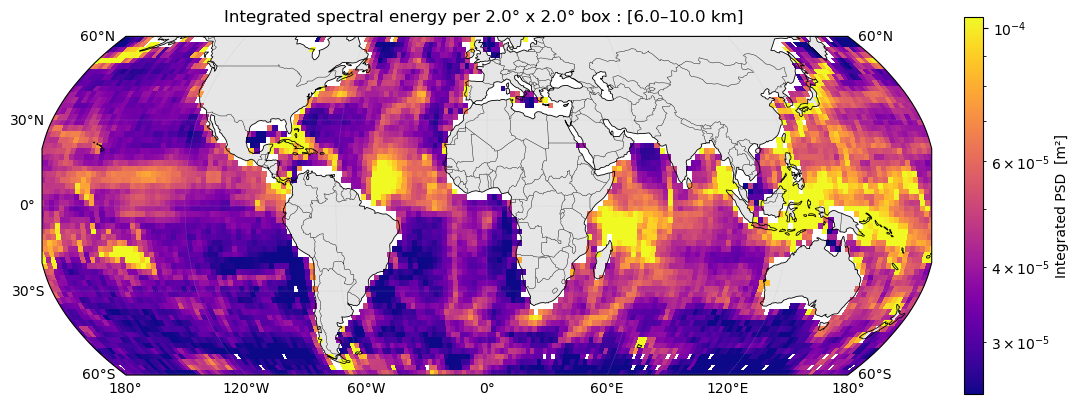

In [163]:
energy = ds_boxes["mean_psd"].sel(wavenumber=slice(1/50,1/10)).integrate('wavenumber')
    
fig, ax = plot_box(energy,ds_boxes["lon_mean"].values,ds_boxes["lat_mean"].values,
                       cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/k_max[-2]:.1f}–{1/k_min[-2]:.1f} km] ",
                       label='Integrated PSD  [m²]',
                      norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                           vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

### Averaged spectra: zonal and meridional averages

Boxes with fewer than `MIN_SEGMENTS_PER_BOX` segments are excluded to avoid noisy estimates.

7717 boxes with ≥ 25 segments


/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension lat_center because variable lat_center is not a coordinate. To create an index for lat_center, please first call `.set_coords('lat_center')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_44020/1318757726.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


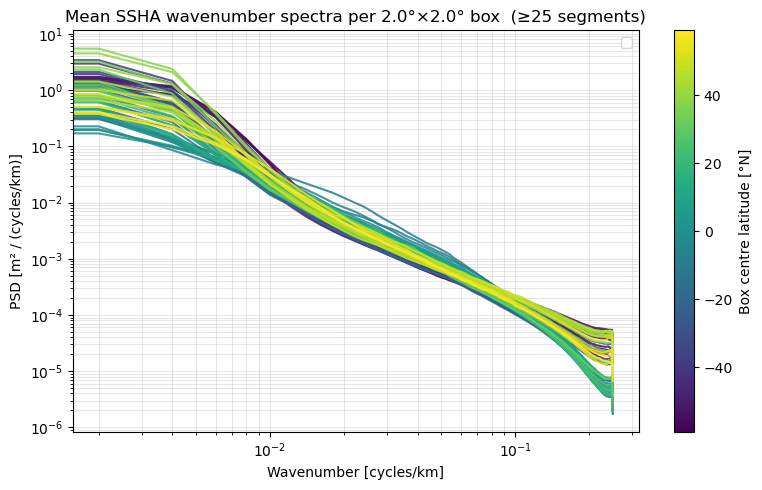

In [18]:
# Zonal average


print(f"{ds_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lat_vals = ds_boxes["lat_center"].values
norm = plt.Normalize(vmin=lat_vals.min(), vmax=lat_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))
box = ds_boxes.groupby('lat_center').mean()
#for i in range(good_boxes.sizes["box"]):
    #box = good_boxes.isel(box=i)
for i in range(box.sizes["lat_center"]):
    lat_box = box.isel(lat_center = i)
    ax.loglog(lat_box["wavenumber"], lat_box["mean_psd"],color=cmap(norm(float(lat_box["lat_center"]))),lw=1.5, alpha=0.85)

# Reference slopes
if False:
    k_ref = ds_boxes["wavenumber"].values[2:]
    psd0  = float(ds_boxes["mean_psd"].isel(box=0).values[2])
    k0    = k_ref[0]
    for exp, ls in ((-2, "--"), (-11/3, ":"),(-5,"+-")):
        lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
        ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension lon_center because variable lon_center is not a coordinate. To create an index for lon_center, please first call `.set_coords('lon_center')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_44020/1610497050.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend();


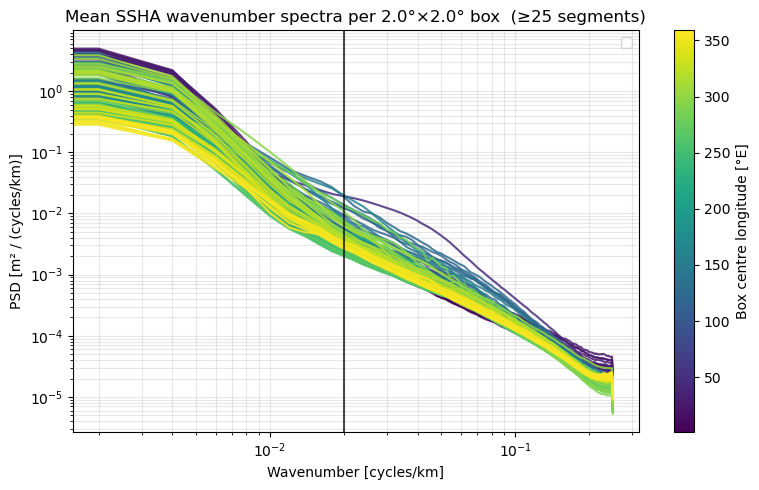

In [19]:
#Meridional average

lon_vals = ds_boxes["lon_center"].values
norm = plt.Normalize(vmin=lon_vals.min(), vmax=lon_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))
box = ds_boxes.groupby('lon_center').mean()
#for i in range(good_boxes.sizes["box"]):
    #box = good_boxes.isel(box=i)
for i in range(box.sizes["lon_center"]):
    lon_box = box.isel(lon_center = i)
    ax.loglog(lon_box["wavenumber"], lon_box["mean_psd"],color=cmap(norm(float(lon_box["lon_center"]))),lw=1.5, alpha=0.85)


# Reference slopes
if False:
    k_ref = ds_boxes["wavenumber"].values[2:]
    psd0  = float(ds_boxes["mean_psd"].isel(box=0).values[2])
    k0    = k_ref[0]
    for exp, ls in ((-2, "--"), (-11/3, ":"),(-5,"+-")):
        lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
        ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre longitude [°E]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend();
ax.axvline(1/50,ls='-',c='k',alpha=0.7)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_44020/746982478.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


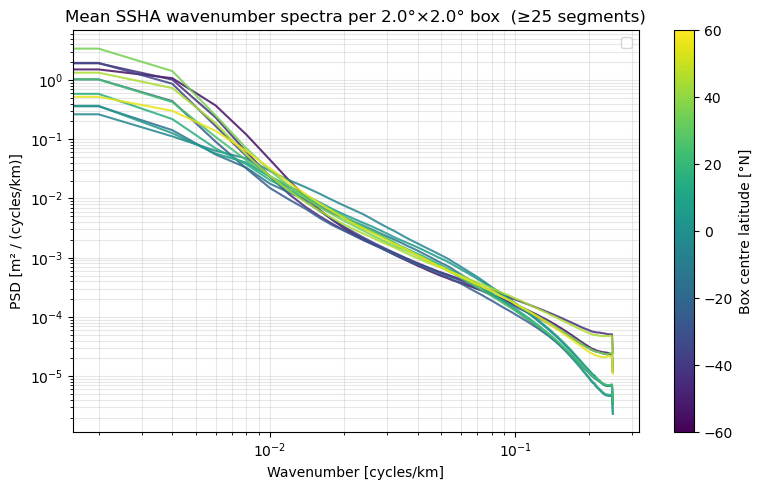

In [20]:
LAT_BIN_EDGES = np.arange(-60, 61, 10)  # adjust to the pass's latitude range

binned = ds_boxes.groupby_bins("lat_center", LAT_BIN_EDGES).mean()
lat_vals = binned["lat_center_bins"].values
norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap("viridis")

box=binned

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(box.sizes["lat_center_bins"]):
    lat_box = box.isel(lat_center_bins = i)
    ax.loglog(lat_box["wavenumber"], lat_box["mean_psd"],color=cmap(norm(float(lat_box["lat_center"]))),lw=1.5, alpha=0.85)

# Reference slopes
if False:
    k_ref = ds_boxes["wavenumber"].values[2:]
    psd0  = float(ds_boxes["mean_psd"].isel(box=0).values[2])
    k0    = k_ref[0]
    for exp, ls in ((-2, "--"), (-11/3, ":"),(-5,"+-")):
        lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
        ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()


/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_44020/1776246028.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


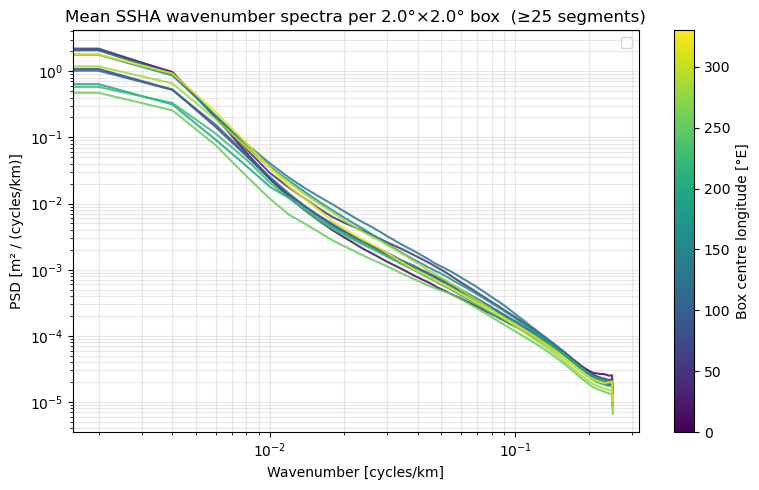

In [21]:

LON_BIN_EDGES = np.arange(0, 360, 30)  # adjust to the pass's latitude range

binned = ds_boxes.groupby_bins("lon_center", LON_BIN_EDGES).mean()
lon_vals = binned["lon_center_bins"].values
norm = plt.Normalize(vmin=np.min(LON_BIN_EDGES), vmax=np.max(LON_BIN_EDGES))
cmap = plt.get_cmap("viridis")

box=binned

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(box.sizes["lon_center_bins"]):
    lon_box = box.isel(lon_center_bins = i)
    ax.loglog(lon_box["wavenumber"], lon_box["mean_psd"],color=cmap(norm(float(lon_box["lon_center"]))),lw=1.5, alpha=0.85)

# Reference slopes
if False:
    k_ref = ds_boxes["wavenumber"].values[2:]
    psd0  = float(ds_boxes["mean_psd"].isel(box=0).values[2])
    k0    = k_ref[0]
    for exp, ls in ((-2, "--"), (-11/3, ":"),(-5,"+-")):
        lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
        ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre longitude [°E]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
